In [1]:
import scanpy as sc

In [2]:
import matplotlib
import matplotlib.pyplot as plt
import os
os.chdir("/public/home/off_liukunpeng/project/11_cluster_problem")
import sys
sys.path.append("/public/home/off_liukunpeng/project/11_cluster_problem/package/")
import glob
import pandas as pd
from matplotlib.lines import Line2D
import numpy as np

In [3]:
from sklearn import metrics
def supervise_index(adata,predict,real_key):
    
    ARI = metrics.adjusted_rand_score(adata.obs[real_key],adata.obs[predict])
    NMI = metrics.normalized_mutual_info_score(adata.obs[real_key],adata.obs[predict])
    FMS = metrics.fowlkes_mallows_score(adata.obs[real_key],adata.obs[predict])
    AMI = metrics.adjusted_mutual_info_score(adata.obs[real_key],adata.obs[predict])
    HMG = metrics.homogeneity_score(adata.obs[real_key],adata.obs[predict])
    VMS = metrics.v_measure_score(adata.obs[real_key],adata.obs[predict])
    MIS = metrics.mutual_info_score(adata.obs[real_key],adata.obs[predict])
    return {"ARI":ARI,
            "NMI":NMI,
            "FMS":FMS,
            "AMI":AMI,
            "HMG":HMG,
            "VMS":VMS,
            'MIS':MIS}
def search_res(adata, n_clusters, method='leiden', use_rep='emb', start=0.1, end=3.0, increment=0.01):
    '''\
    Searching corresponding resolution according to given cluster number
    
    Parameters
    ----------
    adata : anndata
        AnnData object of spatial data.
    n_clusters : int
        Targetting number of clusters.
    method : string
        Tool for clustering. Supported tools include 'leiden' and 'louvain'. The default is 'leiden'.    
    use_rep : string
        The indicated representation for clustering.
    start : float
        The start value for searching.
    end : float 
        The end value for searching.
    increment : float
        The step size to increase.
        
    Returns
    -------
    res : float
        Resolution.
        
    '''
    print('Searching resolution...')
    label = 0
    sc.pp.neighbors(adata, n_neighbors=50, use_rep=use_rep)
    for res in sorted(list(np.arange(start, end, increment)), reverse=True):
        if method == 'leiden':
           sc.tl.leiden(adata, random_state=0, resolution=res)
           count_unique = len(pd.DataFrame(adata.obs['leiden']).leiden.unique())
           print('resolution={}, cluster number={}'.format(res, count_unique))
        elif method == 'louvain':
           sc.tl.louvain(adata, random_state=0, resolution=res)
           count_unique = len(pd.DataFrame(adata.obs['louvain']).louvain.unique()) 
           print('resolution={}, cluster number={}'.format(res, count_unique))
        if count_unique == n_clusters:
            label = 1
            break

    assert label==1, "Resolution is not found. Please try bigger range or smaller step!." 
       
    return res  

In [4]:
!ls comparison/*/*Simulation1*

comparison/cosmos/Dataset13_Simulation1.h5ad
comparison/deepst/Dataset13_Simulation1_RNA.h5ad
comparison/MOFA/Dataset13_Simulation1.h5ad
comparison/multivi/Dataset13_Simulation1.h5ad
comparison/spaGCN/Dataset13_Simulation1_RNA.h5ad
comparison/spatial_glue/Dataset13_Simulation1.h5ad
comparison/STAGATE/Dataset13_Simulation1_RNA.h5ad
comparison/STMGraph/Dataset13_Simulation1_RNA.h5ad
comparison/totalVI/Dataset13_Simulation1.h5ad


In [82]:
simulated_i=5

AgaeSMO_path=f"test_2/simulation/Dataset{12+simulated_i}_Simulation{simulated_i}.h5ad"
COSMOS_path_=f"comparison/cosmos/Dataset{12+simulated_i}_Simulation{simulated_i}.h5ad"
deepst_path_=f"comparison/deepst/Dataset{12+simulated_i}_Simulation{simulated_i}_RNA.h5ad"
mofa_path___=f"comparison/MOFA/Dataset{12+simulated_i}_Simulation{simulated_i}.h5ad"
multivi_path=f"comparison/multivi/Dataset{12+simulated_i}_Simulation{simulated_i}.h5ad"
spaGCN_path_=f"comparison/spaGCN/Dataset{12+simulated_i}_Simulation{simulated_i}_RNA.h5ad"
spatialgpath=f"comparison/spatial_glue/Dataset{12+simulated_i}_Simulation{simulated_i}.h5ad"
STAGATE_path=f"comparison/STAGATE/Dataset{12+simulated_i}_Simulation{simulated_i}_RNA.h5ad"
STMGraphpath=f"comparison/STMGraph/Dataset{12+simulated_i}_Simulation{simulated_i}_RNA.h5ad"
totalVI_path=f"comparison/totalVI/Dataset{12+simulated_i}_Simulation{simulated_i}.h5ad"


In [83]:
AgaeSMO_adata=sc.read_h5ad(AgaeSMO_path)
COSMOS__adata=sc.read_h5ad(COSMOS_path_)
deepst__adata=sc.read_h5ad(deepst_path_)
mofa____adata=sc.read_h5ad(mofa_path___)
multivi_adata=sc.read_h5ad(multivi_path)
spaGCN__adata=sc.read_h5ad(spaGCN_path_)
spatialgadata=sc.read_h5ad(spatialgpath)
STAGATE_adata=sc.read_h5ad(STAGATE_path)
STMGraphadata=sc.read_h5ad(STMGraphpath)
totalVI_adata=sc.read_h5ad(totalVI_path)

In [84]:
search_res(mofa____adata,5,use_rep='X_mofa'   , start=0.0, end=0.8, increment=0.01)
search_res(multivi_adata,5,use_rep='X_MultiVI', start=0.0, end=0.5, increment=0.01)
search_res(totalVI_adata,5,use_rep='X_totalVI', start=0.0, end=0.5, increment=0.01)

Searching resolution...
resolution=0.79, cluster number=5
Searching resolution...
resolution=0.49, cluster number=7
resolution=0.48, cluster number=7
resolution=0.47000000000000003, cluster number=7
resolution=0.46, cluster number=8
resolution=0.45, cluster number=8
resolution=0.44, cluster number=8
resolution=0.43, cluster number=7
resolution=0.42, cluster number=8
resolution=0.41000000000000003, cluster number=8
resolution=0.4, cluster number=8
resolution=0.39, cluster number=7
resolution=0.38, cluster number=7
resolution=0.37, cluster number=7
resolution=0.36, cluster number=6
resolution=0.35000000000000003, cluster number=6
resolution=0.34, cluster number=6
resolution=0.33, cluster number=6
resolution=0.32, cluster number=6
resolution=0.31, cluster number=6
resolution=0.3, cluster number=6
resolution=0.29, cluster number=6
resolution=0.28, cluster number=6
resolution=0.27, cluster number=5
Searching resolution...
resolution=0.49, cluster number=8
resolution=0.48, cluster number=8
r

0.31

In [85]:
ground_truth=1*np.array(AgaeSMO_adata.obsm['spfac'][:,0] + 2*AgaeSMO_adata.obsm['spfac'][:,1] + 3*AgaeSMO_adata.obsm['spfac'][:,2] + 4*AgaeSMO_adata.obsm['spfac'][:,3])
ground_truth=[str(int(i)) for i in ground_truth]

for i in [
AgaeSMO_adata,
COSMOS__adata,
deepst__adata,
mofa____adata,
multivi_adata,
spaGCN__adata,
spatialgadata,
STAGATE_adata,
STMGraphadata,
totalVI_adata,
]:
    i.obs['Ground Truth']=  ground_truth

In [88]:
AgaeSMO_adata.uns["indexes"]=supervise_index(AgaeSMO_adata,"AgaeSMO",               'Ground Truth')
COSMOS__adata.uns["indexes"]=supervise_index(COSMOS__adata,"Cluster_cosmos",      'Ground Truth')
deepst__adata.uns["indexes"]=supervise_index(deepst__adata,"DeepST_refine_domain",'Ground Truth')
mofa____adata.uns["indexes"]=supervise_index(mofa____adata,"leiden",              'Ground Truth')
multivi_adata.uns["indexes"]=supervise_index(multivi_adata,"leiden",              'Ground Truth')
spaGCN__adata.uns["indexes"]=supervise_index(spaGCN__adata,"refined_pred",        'Ground Truth')
spatialgadata.uns["indexes"]=supervise_index(spatialgadata,"SpatialGlue",         'Ground Truth')
STAGATE_adata.uns["indexes"]=supervise_index(STAGATE_adata,"mclust",              'Ground Truth')
STMGraphadata.uns["indexes"]=supervise_index(STMGraphadata,"refine_mclust",       'Ground Truth')
totalVI_adata.uns["indexes"]=supervise_index(totalVI_adata,"leiden",              'Ground Truth')

In [89]:
AgaeSMO_adata.uns["indexes"]

{'ARI': 0.993645642077442,
 'NMI': 0.990034055510304,
 'FMS': 0.9950847331146999,
 'AMI': 0.9899938916759937,
 'HMG': 0.9897707269196812,
 'VMS': 0.9900340555103041,
 'MIS': 1.5315968940189122}

In [90]:
import seaborn as sns
def plot_weight_value(alpha, label, modality1='mRNA', modality2='protein',show=True):
  """\
  Plotting weight values
  
  """  
  import pandas as pd  
  
  df = pd.DataFrame(columns=[modality1, modality2, 'label'])  
  df[modality1], df[modality2] = alpha[:, 0], alpha[:, 1]
  df['label'] = label
  df = df.set_index('label').stack().reset_index()
  df.columns = ['label', 'Modality', 'Weight value']
  return df
  ax = sns.violinplot(data=df, y='Weight value', hue="Modality",
                split=True, inner="quart", linewidth=1)
  ax.set_title(modality1 + ' vs ' + modality2) 

  plt.tight_layout(w_pad=0.05)
  if show:
    plt.show() 
from matplotlib.lines import Line2D







/public/home/off_liukunpeng/software/anaconda3/envs/pyg1/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/public/home/off_liukunpeng/software/anaconda3/envs/pyg1/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/public/home/off_liukunpeng/software/anaconda3/envs/pyg1/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to a

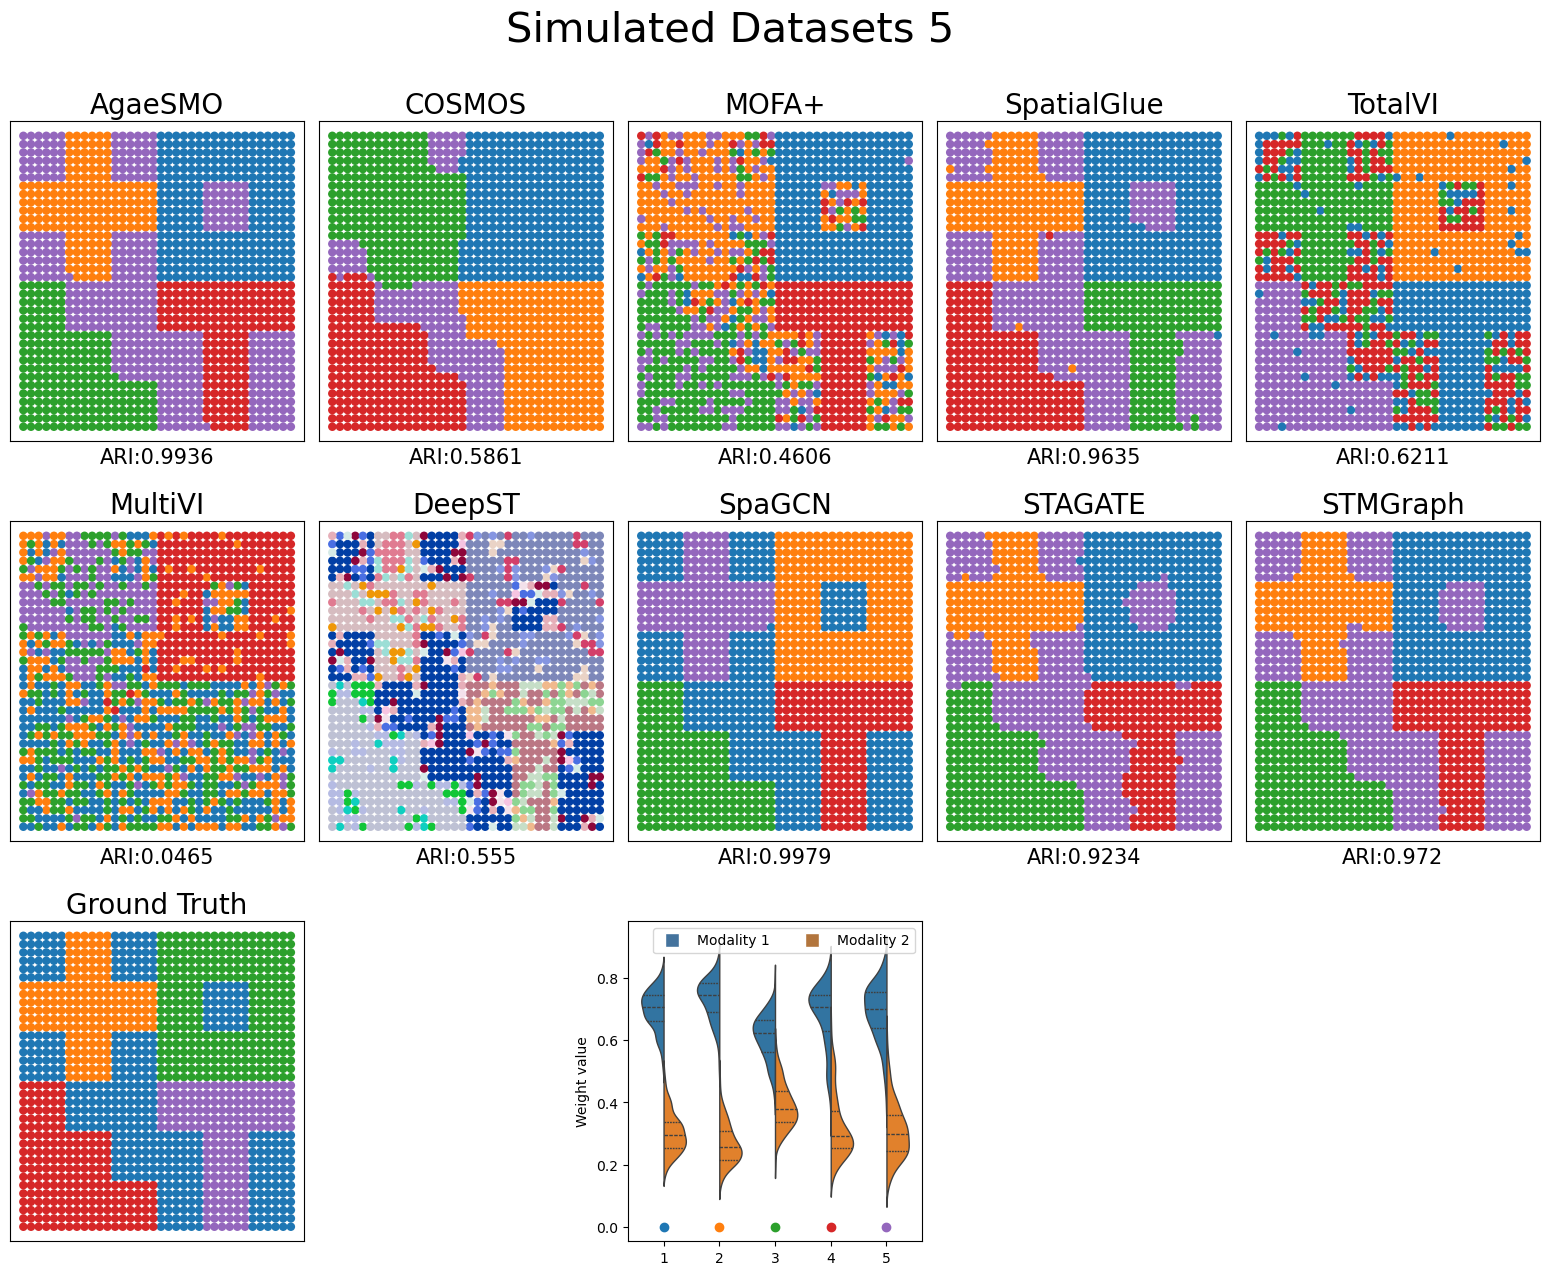

In [91]:
fig,ax=plt.subplots(3,5,figsize=(18,14))
plt.subplots_adjust(left=0.1, bottom=0.1, right=0.95, top=0.9, wspace=0.05, hspace=0.25)
size=150
obs_key=["mclust","refine_mclust",'refined_pred','DeepST_refine_domain',"leiden",'leiden','leiden','SpatialGlue','AgaeSMO']
sc.pl.embedding(AgaeSMO_adata, basis='spatial',color="AgaeSMO",               title=f"AgaeSMO",      ax=ax[0,0] ,s=size, show=False)
sc.pl.embedding(COSMOS__adata, basis='spatial',color="Cluster_cosmos",      title=f"COSMOS",       ax=ax[0,1] ,s=size, show=False)
sc.pl.embedding(mofa____adata, basis='spatial',color="leiden",              title=f"MOFA+",        ax=ax[0,2] ,s=size, show=False)
sc.pl.embedding(spatialgadata, basis='spatial',color="SpatialGlue",         title=f"SpatialGlue",  ax=ax[0,3] ,s=size, show=False)
sc.pl.embedding(totalVI_adata, basis='spatial',color="leiden",              title=f"TotalVI",      ax=ax[0,4] ,s=size, show=False)
sc.pl.embedding(multivi_adata, basis='spatial',color="leiden",              title=f"MultiVI",      ax=ax[1,0] ,s=size, show=False)
sc.pl.embedding(deepst__adata, basis='spatial',color="DeepST_refine_domain",title=f"DeepST",       ax=ax[1,1] ,s=size, show=False)
sc.pl.embedding(spaGCN__adata, basis='spatial',color="refined_pred",        title=f"SpaGCN",       ax=ax[1,2] ,s=size, show=False)
sc.pl.embedding(STAGATE_adata, basis='spatial',color="mclust",              title=f"STAGATE",      ax=ax[1,3] ,s=size, show=False)
sc.pl.embedding(STMGraphadata, basis='spatial',color="refine_mclust",       title=f"STMGraph",     ax=ax[1,4] ,s=size, show=False)

sc.pl.embedding(AgaeSMO_adata, basis='spatial',color='Ground Truth',               title=f'Ground Truth',      ax=ax[2,0] ,s=size, show=False)
# sc.pl.embedding(adatas[8], basis='spatial',color="Ground Truth",title=f"Ground Truth",ax=ax[1,0] ,s=size, show=False)
for i in ax:
    for j in i:
        j.set_xlabel(None)
        j.set_ylabel(None)
        j.set_title(j.title.get_text(), fontsize=20)
        legend = j.legend()
        legend.set_visible(False)  # 隐藏图例
AgaeSMO_ARI=round(AgaeSMO_adata.uns["indexes"]["ARI"],4)
COSMOS__ARI=round(COSMOS__adata.uns["indexes"]["ARI"],4)
mofa____ARI=round(mofa____adata.uns["indexes"]["ARI"],4)
spatialgARI=round(spatialgadata.uns["indexes"]["ARI"],4)
totalVI_ARI=round(totalVI_adata.uns["indexes"]["ARI"],4)
multivi_ARI=round(multivi_adata.uns["indexes"]["ARI"],4)
deepst__ARI=round(deepst__adata.uns["indexes"]["ARI"],4)
spaGCN__ARI=round(spaGCN__adata.uns["indexes"]["ARI"],4)
STAGATE_ARI=round(STAGATE_adata.uns["indexes"]["ARI"],4)
STMGraphARI=round(STMGraphadata.uns["indexes"]["ARI"],4)
ax[0,0].set_xlabel(f"ARI:{AgaeSMO_ARI}",fontsize=15)
ax[0,1].set_xlabel(f"ARI:{COSMOS__ARI}",fontsize=15)
ax[0,2].set_xlabel(f"ARI:{mofa____ARI}",fontsize=15)
ax[0,3].set_xlabel(f"ARI:{spatialgARI}",fontsize=15)
ax[0,4].set_xlabel(f"ARI:{totalVI_ARI}",fontsize=15)
ax[1,0].set_xlabel(f"ARI:{multivi_ARI}",fontsize=15)
ax[1,1].set_xlabel(f"ARI:{deepst__ARI}",fontsize=15)
ax[1,2].set_xlabel(f"ARI:{spaGCN__ARI}",fontsize=15)
ax[1,3].set_xlabel(f"ARI:{STAGATE_ARI}",fontsize=15)
ax[1,4].set_xlabel(f"ARI:{STMGraphARI}",fontsize=15)

for n,i in enumerate(set(AgaeSMO_adata.obs["AgaeSMO"])):
    alpha=AgaeSMO_adata.obsm["alpha"][AgaeSMO_adata.obs["AgaeSMO"]==i,:]
    
    df=plot_weight_value(alpha,"AgaeSMO",modality1='mRNA', modality2='MSI')
    sns.violinplot(data=df,ax=ax[2,2],x=n+1,y='Weight value', hue="Modality",
                split=True, inner="quart", linewidth=1)
    
    ax[2,2].scatter(n,0,c=AgaeSMO_adata.uns["AgaeSMO_colors"][n])
ax[2,2].legend().set_visible(False)
#     ax[j].set_title(titles[j])
#     legend = ax[j].legend()
#     legend.set_visible(False)
#     # break
legend_elements = [
    Line2D([0], [0], marker='s', color='w', label='Modality 1',       markerfacecolor="#44739d", markersize=10),
    Line2D([0], [0], marker='s', color='w', label='Modality 2',       markerfacecolor="#b2753d", markersize=10),
]
ax[2,2].legend(handles=legend_elements, ncol=2,loc= 'upper right' ,fontsize=10)
ax[2,1].set_visible(False)
ax[2,3].set_visible(False)
ax[2,4].set_visible(False)


# for i in ax:
#     for j in i:
#         j.set_xlabel(None)
#         j.set_ylabel(None)
# legend_elements = [
#     Line2D([0], [0], marker='o', color='w', label='0',       markerfacecolor=adatas[0].uns["mclust_colors"][0], markersize=10),
#     Line2D([0], [0], marker='o', color='w', label='1',      markerfacecolor=adatas[0].uns["mclust_colors"][1], markersize=10),
#     Line2D([0], [0], marker='o', color='w', label='2',        markerfacecolor=adatas[0].uns["mclust_colors"][2], markersize=10),
#     Line2D([0], [0], marker='o', color='w', label='3',        markerfacecolor=adatas[0].uns["mclust_colors"][3], markersize=10),
#     Line2D([0], [0], marker='o', color='w', label='4',         markerfacecolor=adatas[0].uns["mclust_colors"][4], markersize=10),
# ]
# ax[0,0].legend(handles=legend_elements, ncol=1,loc= 'upper left' ,fontsize=20,bbox_to_anchor=(-0.5, 1))
# ax[1,0].set_xlabel(None)
# ax[1,0].set_ylabel(None)
# ax[1,0].xaxis.set_visible(False) 
# ax[1,0].yaxis.set_visible(False) 
# ax[1,0].spines['top'].set_visible(False)
# ax[1,0].spines['right'].set_visible(False)
# ax[1,0].spines['left'].set_visible(False)
# ax[1,0].spines['bottom'].set_visible(False)
plt.suptitle(f'Simulated Datasets {simulated_i}',fontsize=30)
fig.savefig(f"plot/s3-7_simulated{simulated_i}")